# 00. Prepare the SST-2 Dataset (run this notebook first)

This notebook downloads the **SST-2** sentiment dataset (Stanford Sentiment Treebank,
binary version, part of the GLUE benchmark) and saves three fixed splits to Google Drive
so that **every model notebook trains and evaluates on exactly the same data**.

**Why we build our own test split.** The official GLUE SST-2 test labels are hidden
(they are all `-1`; scoring happens on the GLUE server). The standard workaround used in
many papers is:

- hold out 5% of the official *train* split as our **validation** set, and
- use the official *validation* split (872 sentences) as our **test** set.

**Outputs written to Drive** (`AMIC project/sst2_benchmark/data/`):
`sst2_train.csv`, `sst2_valid.csv`, `sst2_test.csv`, each with two columns:
`text` (the sentence) and `y` (1 = positive, 0 = negative).

Run order for the whole benchmark: **00 → 01 (BAMIC) → 02 → 03 → 04 → 05 → 06 → 07.**

In [1]:
# ================================================================
# 0. Check the Colab GPU
# ================================================================

# Ask the Colab runtime which GPU we were given.
gpu_info = !nvidia-smi
# Join the command output lines into one printable string.
gpu_info = '\n'.join(gpu_info)
# If the command failed, we are not connected to a GPU runtime.
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU. In Colab: Runtime -> Change runtime type -> T4 GPU.')
else:
    print(gpu_info)

Sun Aug  2 18:22:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# ================================================================
# 1. Check the Colab RAM
# ================================================================

# psutil reports how much system memory this runtime has.
import psutil
# Convert bytes to gigabytes for a readable number.
ram_gb = psutil.virtual_memory().total / 1e9
# Print the available RAM so we know which runtime type we received.
print('Your runtime has {:.1f} gigabytes of available RAM'.format(ram_gb))

Your runtime has 179.4 gigabytes of available RAM


In [3]:
# ================================================================
# 2. Basic imports and reproducibility (no Hugging Face account needed)
# ================================================================

# pathlib gives clean, operating-system-safe file paths.
from pathlib import Path

# random controls Python-level randomness.
import random

# io lets us treat downloaded bytes like a file.
import io

# zipfile unpacks the downloaded SST-2 archive.
import zipfile

# requests downloads the dataset zip over plain HTTPS (no login, no token).
import requests

# numpy handles numeric arrays.
import numpy as np

# pandas handles CSV data tables.
import pandas as pd

# train_test_split creates a reproducible stratified holdout.
from sklearn.model_selection import train_test_split

# This seed keeps the split identical every time (same seed as the wine notebooks).
SEED = 20260526

# Seed Python's random module.
random.seed(SEED)

# Seed NumPy's random generator.
np.random.seed(SEED)

In [4]:
# ================================================================
# 3. Mount Google Drive and define project paths
# ================================================================

# Mount Google Drive so Colab can read and write project files.
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

# This is the same Google Drive project folder used by the wine BAMIC notebooks.
# If your folder name is different in Drive, edit only this line.
PROJECT_DIR = Path('/content/drive/MyDrive/AMIC project')

# All SST-2 benchmark files live inside this subfolder.
BENCH_DIR = PROJECT_DIR / 'sst2_benchmark'

# The shared, prepared SST-2 splits are stored here by notebook 00.
DATA_DIR = BENCH_DIR / 'data'

# This notebook writes all of its results into its own output folder.
EXPERIMENT_NAME = 'sst2_data_prep'
OUTPUT_DIR = DATA_DIR  # the prepared CSVs ARE this notebook's output

# Create the output folder if it does not exist yet.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Print the paths so we can verify them before loading data.
print('PROJECT_DIR:', PROJECT_DIR)
print('DATA_DIR   :', DATA_DIR)
print('OUTPUT_DIR :', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
PROJECT_DIR: /content/drive/MyDrive/AMIC project
DATA_DIR   : /content/drive/MyDrive/AMIC project/sst2_benchmark/data
OUTPUT_DIR : /content/drive/MyDrive/AMIC project/sst2_benchmark/data


In [5]:
# ================================================================
# 4. Download SST-2 directly from the official GLUE mirror
# ================================================================

# This is the official public GLUE data mirror: a plain HTTPS zip download.
# It needs NO Hugging Face account, token, or Colab secret.
SST2_URL = 'https://dl.fbaipublicfiles.com/glue/data/SST-2.zip'

# Skip the download entirely if the prepared CSVs already exist in Drive.
# (This also means you can simply upload the three CSVs to DATA_DIR by hand
# and re-run this notebook without downloading anything.)
already_prepared = all((DATA_DIR / name).exists()
                       for name in ['sst2_train.csv', 'sst2_valid.csv', 'sst2_test.csv'])
print('Prepared CSVs already in Drive:', already_prepared)

if not already_prepared:
    # Download the zip archive into memory (about 7 MB).
    print('Downloading', SST2_URL)
    response = requests.get(SST2_URL, timeout=120)
    # Stop with a clear error if the server did not return the file.
    response.raise_for_status()
    # Open the downloaded bytes as a zip archive.
    archive = zipfile.ZipFile(io.BytesIO(response.content))
    # List the files inside so we can see what the archive contains.
    print('Archive contents:', archive.namelist()[:5])
    # Read the official train split (TSV: sentence <tab> label).
    # quoting=3 (QUOTE_NONE) matches how the GLUE files are written.
    official_train = pd.read_csv(archive.open('SST-2/train.tsv'), sep='\t', quoting=3)
    # Read the official dev split, which will become our labeled test set.
    official_valid = pd.read_csv(archive.open('SST-2/dev.tsv'), sep='\t', quoting=3)
    # Keep only the two columns we need and use the same names as the wine notebooks.
    official_train = official_train.rename(columns={'sentence': 'text', 'label': 'y'})[['text', 'y']]
    official_valid = official_valid.rename(columns={'sentence': 'text', 'label': 'y'})[['text', 'y']]
    # Print the official split sizes as a sanity check (67,349 train / 872 dev).
    print('official train:', official_train.shape)
    print('official dev  :', official_valid.shape)
    # Show two example sentences so we can see what the data looks like.
    display(official_train.head(2))

Prepared CSVs already in Drive: False
Archive contents: ['SST-2/', 'SST-2/dev.tsv', 'SST-2/original/', 'SST-2/original/README.txt', 'SST-2/original/SOStr.txt']
official train: (67349, 2)
official dev  : (872, 2)


,text,y
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0


In [6]:
# ================================================================
# 5. Build our train/valid/test splits
# ================================================================

if already_prepared:
    # The CSVs are already in Drive, so just load them back for the checks below.
    train_df = pd.read_csv(DATA_DIR / 'sst2_train.csv')
    valid_df = pd.read_csv(DATA_DIR / 'sst2_valid.csv')
    test_df = pd.read_csv(DATA_DIR / 'sst2_test.csv')
else:
    # Hold out 5% of the official train split as our validation set.
    # stratify=y keeps the positive/negative ratio identical in both parts.
    train_df, valid_df = train_test_split(
        official_train,
        test_size=0.05,
        random_state=SEED,
        stratify=official_train['y'],
    )
    # The official GLUE validation split becomes our labeled test set.
    test_df = official_valid.copy()
    # Reset the row indices so the saved CSVs are clean.
    train_df = train_df.reset_index(drop=True)
    valid_df = valid_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

# Print the final sizes and label balance of each split.
# Expected: train (63981, 2), valid (3368, 2), test (872, 2).
print('train:', train_df.shape, '| positive rate:', round(train_df['y'].mean(), 4))
print('valid:', valid_df.shape, '| positive rate:', round(valid_df['y'].mean(), 4))
print('test :', test_df.shape, '| positive rate:', round(test_df['y'].mean(), 4))

train: (63981, 2) | positive rate: 0.5578
valid: (3368, 2) | positive rate: 0.5579
test : (872, 2) | positive rate: 0.5092


count    63981.000000
mean         9.409153
std          8.081696
min          1.000000
25%          3.000000
50%          7.000000
75%         13.000000
max         52.000000
Name: text, dtype: float64
Share of train sentences with <= 60 tokens: 1.0


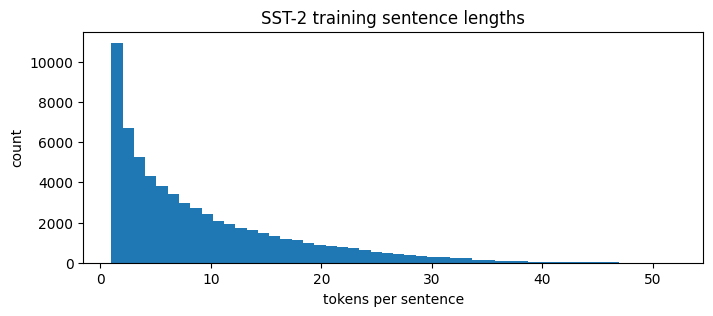

In [7]:
# ================================================================
# 6. Quick look at sentence lengths (informs MAX_LEN in the model notebooks)
# ================================================================

# matplotlib draws the histogram.
import matplotlib.pyplot as plt

# Count whitespace-separated tokens per training sentence.
lengths = train_df['text'].str.split().str.len()

# Print summary statistics of the length distribution.
print(lengths.describe())

# Print the share of sentences that fit within 60 tokens.
print('Share of train sentences with <= 60 tokens:', round((lengths <= 60).mean(), 4))

# Draw a simple histogram of sentence lengths.
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50)
plt.xlabel('tokens per sentence')
plt.ylabel('count')
plt.title('SST-2 training sentence lengths')
plt.show()

In [8]:
# ================================================================
# 7. Save the shared splits to Drive
# ================================================================

# Every model notebook will read these three files, so we save them once here.
# (When the CSVs were already in Drive, this simply rewrites identical files.)
train_df.to_csv(DATA_DIR / 'sst2_train.csv', index=False)
valid_df.to_csv(DATA_DIR / 'sst2_valid.csv', index=False)
test_df.to_csv(DATA_DIR / 'sst2_test.csv', index=False)

# Confirm the files now exist in Drive.
for name in ['sst2_train.csv', 'sst2_valid.csv', 'sst2_test.csv']:
    path = DATA_DIR / name
    print(path, '| exists:', path.exists(), '| rows:', len(pd.read_csv(path)))

/content/drive/MyDrive/AMIC project/sst2_benchmark/data/sst2_train.csv | exists: True | rows: 63981
/content/drive/MyDrive/AMIC project/sst2_benchmark/data/sst2_valid.csv | exists: True | rows: 3368
/content/drive/MyDrive/AMIC project/sst2_benchmark/data/sst2_test.csv | exists: True | rows: 872


**Done.** The three shared splits are saved. You can now run any model notebook (01–07).